This is a space for minor tasks related with $^{83\text{m}}\text{Kr}$ data, e.g:

- Plot parameters evolution from Gonzalo's analysis results (Rn-paper).
- Check _Zemrude_ (new ICAROS) results by comparison with the above ones.

In [1]:
import sys
sys.path.append('/lhome/ific/c/ccortesp/Analysis')

from libs import crudo
from libs import fit_functions as ff
from libs import plotting_tools as pt

import h5py
from   iminuit import Minuit
from   iminuit.cost import LeastSquares
from   matplotlib.offsetbox import (OffsetImage, AnnotationBbox)
import matplotlib.pyplot as plt
import numpy as np
import os
import pandas as pd
import pickle
from   PIL import Image
import scipy
from   scipy.optimize import curve_fit

# Styling Plot
pt.ccortesp_plot_style()
PRELIM_LOGO = np.asarray(Image.open('/lhome/ific/c/ccortesp/Analysis/images/next_logo_preliminary.png'))

%matplotlib inline
%load_ext autoreload
%autoreload 2

# Lifetime Evolution (Rn Paper)

In [2]:
# Main directories and files
KR_H5 = '/lhome/ific/c/ccortesp/Analysis/temp/h5/energy_scale_lowbg_fullrun.h5'
OUTPUT_PAPER = '/lhome/ific/c/ccortesp/Papers/RnLPRPaper/fig/'

# Load dataframe
KR_DF = pd.read_hdf(KR_H5)
KR_DF

,time,e0,e0u,elt,eltu,run,ts
0,1.753147e+09,8252.197461,0.149931,31.471374,0.589599,15609,2025-07-22 03:23:44.556530
1,1.753244e+09,8253.163180,0.227370,31.351767,0.562935,15614,2025-07-23 06:16:04.995733
2,1.753328e+09,8249.267515,0.218222,34.606192,0.661172,15615,2025-07-24 05:35:10.046992
3,1.753414e+09,8252.333704,0.223355,33.222847,0.586962,15616,2025-07-25 05:19:43.844530
4,1.753502e+09,8271.984477,0.200530,33.216925,0.680802,15617,2025-07-26 05:45:26.006479
...,...,...,...,...,...,...,...
62,1.758939e+09,8225.667036,0.150743,32.328149,0.478259,15733,2025-09-27 04:17:05.048126
63,1.759026e+09,8236.656797,0.125764,33.568633,0.527629,15734,2025-09-28 04:15:57.620727
64,1.759112e+09,8239.187861,0.122069,33.482072,0.501514,15735,2025-09-29 04:15:27.553136
65,1.759203e+09,8237.806970,0.135477,33.964985,0.513820,15736,2025-09-30 05:32:37.118072


In [3]:
# --- Extracting Data --- #
Run_numbers = np.array(KR_DF['run'].astype(int))
Date = np.array(KR_DF['time'])
# Light yield
Yield_cv  = np.array(KR_DF['e0'])
Yield_err = np.array(KR_DF['e0u'])
# Lifetime
Lifetime_cv  = np.array(KR_DF['elt'])
Lifetime_err = np.array(KR_DF['eltu'])

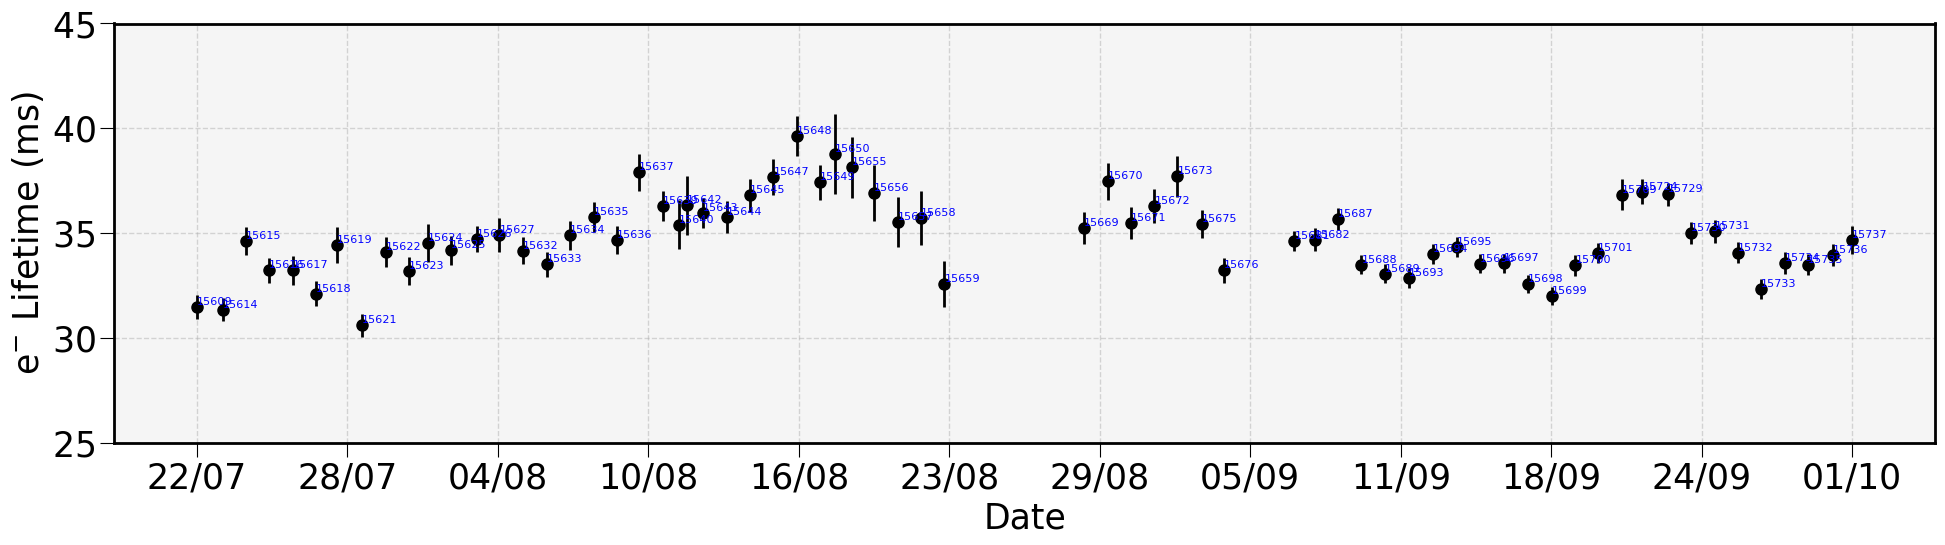

In [66]:
# ----- Plotting ---- #
fig, ax = plt.subplots(figsize=(20, 6))

# Data
plt.errorbar(Date, Lifetime_cv, yerr=Lifetime_err, fmt='o', c='black', ecolor='black')
for x, y, run_id in zip(Date, Lifetime_cv, Run_numbers):
    plt.text(x, y, str(run_id), fontsize=8, ha='left', va='bottom', color='blue')       # Run number near the point

# ---- Styling ---- #
x_labels  = [crudo.epoch_converter(t, h=False) for t in Date]        # Convert x-axis bin edges to readable time format
num_ticks = 12                                                       # Number of ticks to display
uniform_dates = np.linspace(Date.min(), Date.max(), num_ticks)       # Uniformly spaced dates
uniform_labels = [crudo.epoch_converter(t, h=False) for t in uniform_dates]  # Convert to readable format

plt.xlabel('Date')
plt.xticks(uniform_dates, uniform_labels, rotation=0, ha='center')
plt.ylabel(r'e$^{-}$ Lifetime (ms)')
plt.ylim(25, 45)

plt.grid(True)
plt.gca().set_facecolor("whitesmoke")
plt.tight_layout()
# plt.savefig(OUTPUT_PAPER + 'LowBG_Lifetime.pdf')
plt.show()

# Zemrude Test

### 05/03/2026

In [4]:
# --- Paths & Filenames --- #
ZEMRUDE_PATH = "/lustre/ific.uv.es/prj/gl/neutrinos/users/ccortesp/NEXT-100/Icaros/Low_background/2025/"
# test_file = "run_15737.zemrude-test-2-gfd7dd555.20250717-26-g211f149.KrDesman.zemrude.h5"
test_file = "run_15648.zemrude-test.20250717-26-g211f149.KrDesman.zemrude.h5"

# Take the run list from Gonzalo's data
list_of_runs = KR_DF['run'].tolist()

# --- Filtered Files --- #
filtered_files = [
                    os.path.join(ZEMRUDE_PATH, file)
                    for file in os.listdir(ZEMRUDE_PATH)
                    if any(str(run) in file for run in list_of_runs) and "zemrude" in file
                 ]
filtered_files = sorted(filtered_files)

In [5]:
# --- Dataframe Definition --- #
LIFETIME_DF = pd.DataFrame(columns=['run', 'time', 'e0', 'e0u', 'elt', 'eltu'])

for path in filtered_files:
    try:
        df = pd.read_hdf(path, key='t_evol/t_evol')
        run_id = int(df['run_number'].iloc[0])
        date_mean = df['ts'].mean()
        e0_mean  = df['e0'].mean()
        e0u_mean = np.sqrt(np.sum(df['e0u']**2)) / len(df)
        lt_mean  = (df['lt'].mean()) / 1e3                            # In [ms]
        ltu_mean = (np.sqrt(np.sum(df['ltu']**2)) / len(df)) / 1e3    # In [ms]
        LIFETIME_DF = LIFETIME_DF.append({'run': run_id, 'time': date_mean, 'e0': e0_mean, 'e0u': e0u_mean, 'elt': lt_mean, 'eltu': ltu_mean}, ignore_index=True)
    except Exception as e:
        print(f"Error processing file {path}: {e}")
    
LIFETIME_DF

,run,time,e0,e0u,elt,eltu
0,15609.0,1.753153e+09,8291.819825,2.465479,33.846047,0.393836
1,15614.0,1.753245e+09,8295.347560,1.688426,33.504966,0.317700
2,15615.0,1.753327e+09,8293.122388,1.554917,32.639766,0.274616
3,15616.0,1.753415e+09,8295.984892,1.598509,31.924695,0.271987
4,15617.0,1.753505e+09,8307.077967,1.782340,35.170461,0.365783
...,...,...,...,...,...,...
62,15733.0,1.758943e+09,8252.601302,1.209393,38.360656,0.359008
63,15734.0,1.759026e+09,8257.972059,1.283507,39.419841,0.330705
64,15735.0,1.759116e+09,8258.892509,1.449823,39.597458,0.380378
65,15736.0,1.759203e+09,8258.500991,1.221893,39.581594,0.318073


#### Comparison plot

In [6]:
# --- Extracting Data --- #
Run_numbers_zem  = np.array(LIFETIME_DF['run'].astype(int))
Date_zem = np.array(LIFETIME_DF['time'])
# Yield
Yield_cv_zem  = np.array(LIFETIME_DF['e0'])
Yield_err_zem = np.array(LIFETIME_DF['e0u'])
# Lifetime
Lifetime_cv_zem  = np.array(LIFETIME_DF['elt'])
Lifetime_err_zem = np.array(LIFETIME_DF['eltu'])

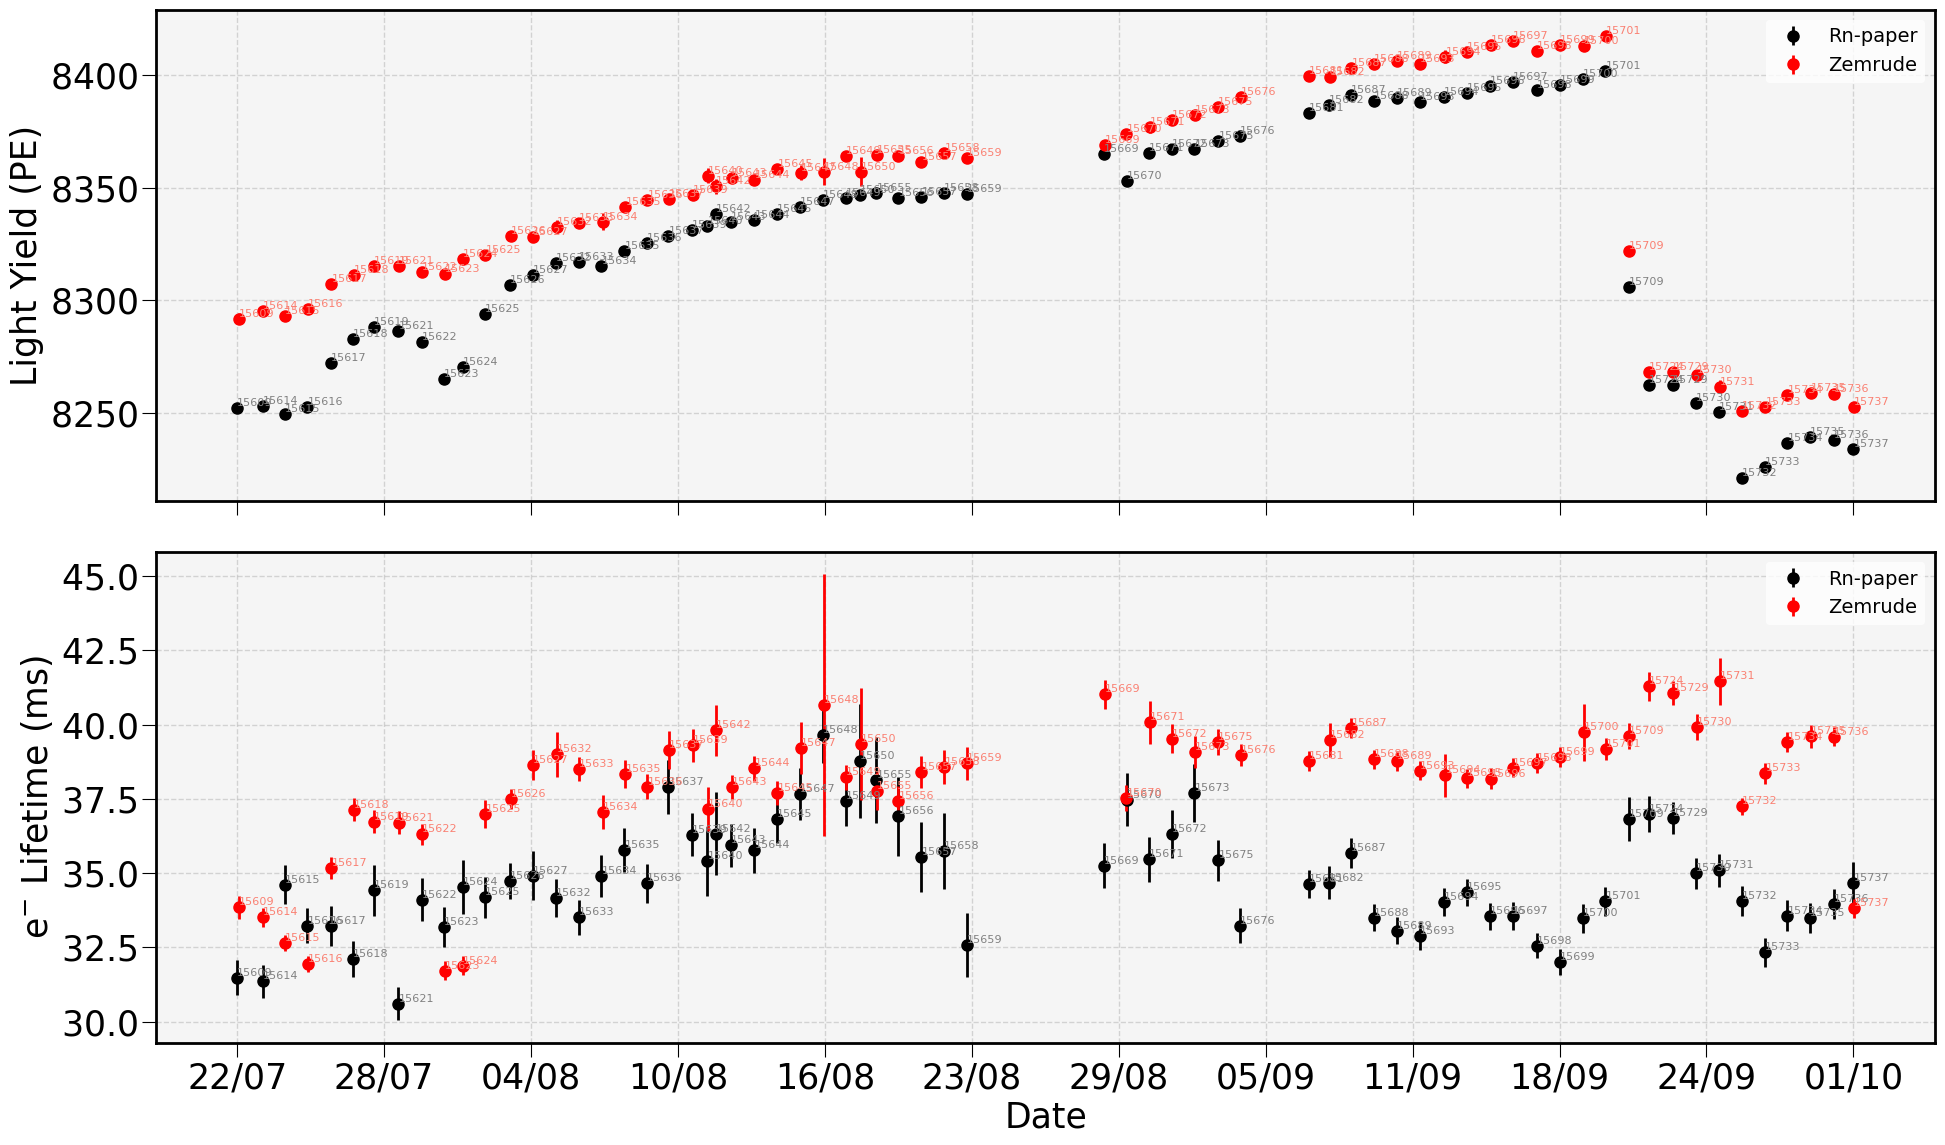

In [7]:
# ----- Plotting ---- #
fig, axs = plt.subplots(2, 1, figsize=(20, 12), sharex=True)

# --- Yield Plot --- #
axs[0].errorbar(Date, Yield_cv, yerr=Yield_err, fmt='o', c='black', ecolor='black', label='Rn-paper')
for x, y, run_id in zip(Date, Yield_cv, Run_numbers):
    axs[0].text(x, y, str(run_id), fontsize=8, ha='left', va='bottom', color='gray')

axs[0].errorbar(Date_zem, Yield_cv_zem, yerr=Yield_err_zem, fmt='o', c='red', ecolor='red', label='Zemrude')
for x, y, run_id in zip(Date_zem, Yield_cv_zem, Run_numbers_zem):
    axs[0].text(x, y, str(run_id), fontsize=8, ha='left', va='bottom', color='salmon')

axs[0].set_ylabel('Light Yield (PE)')
axs[0].legend(fontsize=14)
axs[0].grid(True)
axs[0].set_facecolor("whitesmoke")

# --- Lifetime Plot --- #
axs[1].errorbar(Date, Lifetime_cv, yerr=Lifetime_err, fmt='o', c='black', ecolor='black', label='Rn-paper')
for x, y, run_id in zip(Date, Lifetime_cv, Run_numbers):
    axs[1].text(x, y, str(run_id), fontsize=8, ha='left', va='bottom', color='gray')

axs[1].errorbar(Date_zem, Lifetime_cv_zem, yerr=Lifetime_err_zem, fmt='o', c='red', ecolor='red', label='Zemrude')
for x, y, run_id in zip(Date_zem, Lifetime_cv_zem, Run_numbers_zem):
    axs[1].text(x, y, str(run_id), fontsize=8, ha='left', va='bottom', color='salmon')

axs[1].set_xlabel('Date')
axs[1].set_ylabel(r'e$^{-}$ Lifetime (ms)')
axs[1].legend(fontsize=14)
axs[1].grid(True)
axs[1].set_facecolor("whitesmoke")

# ---- Styling ---- #
x_labels = [crudo.epoch_converter(t, h=False) for t in Date]
num_ticks = 12
uniform_dates = np.linspace(Date.min(), Date.max(), num_ticks)
uniform_labels = [crudo.epoch_converter(t, h=False) for t in uniform_dates]

axs[1].set_xticks(uniform_dates)
axs[1].set_xticklabels(uniform_labels, rotation=0, ha='center')

plt.tight_layout()
plt.show()

#### Test File

In [7]:
# Dataframe
test_path = os.path.join(ZEMRUDE_PATH, test_file)
test_df = pd.read_hdf(test_path, key='t_evol/t_evol')

# Main information
run_id = test_df['run_number'].iloc[0]
date_mean = test_df['ts'].mean()
lt_mean  = (test_df['lt'].mean()) / 1e3                                 # In [ms]
ltu_mean = (np.sqrt(np.sum(test_df['ltu']**2)) / len(test_df)) / 1e3    # In [ms]
e0_mean  = test_df['e0'].mean()
e0u_mean = np.sqrt(np.sum(test_df['e0u']**2)) / len(test_df)

# Summary
print(f"Run: {run_id}, Date: {date_mean:.2f} s, Yield: {e0_mean:.2f}, Yield Error: {e0u_mean:.2f}, Lifetime: {lt_mean:.2f} ms, Lifetime Error: {ltu_mean:.2f} ms")

Run: 15648, Date: 1755372211.77 s, Yield: 8357.03, Yield Error: 6.01, Lifetime: 40.64 ms, Lifetime Error: 4.41 ms


In [78]:
test_df

,run_number,ts,s2e,s2eu,ec1,ec1u,ec2,ec2u,chi2_ec,e0,...,s2q,s2qu,Nsipm,Nsipmu,Xrms,Xrmsu,Yrms,Yrmsu,Zrms,Zrmsu
0,15648,1755332205,7729.062599,1.641585,42.227718,0.002694,41.536075,0.013019,4114.527356,8359.118485,...,567.423362,0.485952,16.929877,0.006813,14.234285,0.004932,14.263874,0.004954,4.240395,0.004526
1,15648,1755334299,7731.404721,1.637715,42.224494,0.002799,41.533309,0.011769,4560.934324,8365.440254,...,567.673433,0.485310,16.933520,0.006784,14.240878,0.004916,14.262742,0.004950,4.239982,0.004524
2,15648,1755343741,7728.294396,1.646910,42.230160,0.002589,41.539381,0.012245,3873.682825,8369.808007,...,567.744447,0.484380,16.930164,0.006764,14.235381,0.004907,14.267303,0.004920,4.242815,0.004507
3,15648,1755349712,7735.801920,1.634072,42.237571,0.002477,41.548075,0.012191,3536.269539,8365.483945,...,567.494438,0.483128,16.943065,0.006805,14.246865,0.004912,14.271080,0.004938,4.244601,0.004497
4,15648,1755361064,7732.496580,1.641605,42.231885,0.002690,41.533792,0.012516,4128.499994,8352.952264,...,568.351986,0.487070,16.934816,0.006783,14.237655,0.004924,14.257920,0.004929,4.238054,0.004532
5,15648,1755368114,7731.933535,1.649883,42.224927,0.002765,41.538695,0.011897,4332.562274,8363.564978,...,567.640773,0.487957,16.929845,0.006820,14.230276,0.004942,14.265850,0.004980,4.241710,0.004529
6,15648,1755371164,7736.385718,1.636124,42.242376,0.002350,41.545646,0.011820,3117.391582,8357.723150,...,567.776213,0.486240,16.932621,0.006814,14.238415,0.004920,14.264831,0.004938,4.243415,0.004521
7,15648,1755376340,7732.492076,1.651584,42.235588,0.002759,41.543503,0.011963,4320.393530,8359.489837,...,568.034647,0.485582,16.932372,0.006801,14.239354,0.004940,14.257913,0.004947,4.236797,0.004535
8,15648,1755389817,7733.597891,1.635601,42.240394,0.002402,41.543330,0.012383,3219.898080,8362.646430,...,567.421049,0.486893,16.934742,0.006821,14.244691,0.004932,14.265291,0.004967,4.239952,0.004528
9,15648,1755391521,7734.505236,1.636412,42.239949,0.002903,41.543782,0.012160,4762.321454,8360.987010,...,568.907698,0.485637,16.928394,0.006781,14.227879,0.004929,14.256172,0.004957,4.230071,0.004533


In [80]:
crudo.h5_describer(test_path)

config (Group)
  config/zemrude (Dataset)
    Shape: (55,), Dtype: [('variable', 'S300'), ('value', 'S300')]
data (Group)
  data/selection_efficiencies (Dataset)
    Shape: (1,), Dtype: [('eff_diffusion_band', '<f8'), ('eff_Xrays', '<f8'), ('eff_1S1_1S2', '<f8'), ('eff_S2_trigger_time', '<f8'), ('eff_Rmax', '<f8'), ('eff_range_DT', '<f8'), ('eff_NSiPMS', '<f8'), ('total_efficiency', '<f8')]
krmap (Group)
  krmap/krmap (Dataset)
    Shape: (100000,), Dtype: [('k', '<i8'), ('i', '<i8'), ('j', '<i8'), ('nevents', '<f8'), ('mu', '<f8'), ('sigma', '<f8'), ('mu_error', '<f8'), ('sigma_error', '<f8'), ('dt', '<f8'), ('x', '<f8'), ('y', '<f8')]
metadata (Group)
  metadata/axis0 (Dataset)
    Shape: (1,), Dtype: int64
  metadata/axis1 (Dataset)
    Shape: (15,), Dtype: |S11
  metadata/block0_items (Dataset)
    Shape: (1,), Dtype: int64
  metadata/block0_values (Dataset)
    Shape: (1,), Dtype: object
t_evol (Group)
  t_evol/t_evol (Dataset)
    Shape: (13,), Dtype: [('run_number', '<i4'), ('ts